# Exploratory Data Analysis (EDA)

## Project
System Capacity & Care Load Analytics for Unaccompanied Children

### Objective

The objective of this notebook is to explore historical operational trends,
identify data quality issues, understand variable relationships,
and generate insights that will support forecasting and machine learning.

### Dataset

Source:
U.S. Department of Health & Human Services

Records:
720

Features:
6 Operational Metrics

Author:
Swimmy Sahaniya

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/processed/clean_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6,18,11,2484,14
1,2025-12-18,11,50,6,2472,16
2,2025-12-17,7,31,11,2481,10
3,2025-12-16,8,54,15,2468,9
4,2025-12-15,11,42,9,2470,7


In [5]:
df.shape

(720, 6)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    int64         
 2   Children in CBP custody                          720 non-null    int64         
 3   Children transferred out of CBP custody          720 non-null    int64         
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 33.9 KB


In [21]:
summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Std": df.std(numeric_only=True),
    "Min": df.min(numeric_only=True),
    "Max": df.max(numeric_only=True)
})

summary

,Mean,Median,Std,Min,Max
Children apprehended and placed in CBP custody*,93.523611,99.0,72.646625,0,333
Children in CBP custody,171.494444,193.0,126.354965,7,531
Children transferred out of CBP custody,128.668056,157.0,97.322012,0,440
Children in HHS Care,6061.275000,6406.5,2833.070109,1972,11516
Children discharged from HHS Care,173.406944,181.0,125.702841,0,505
Year,2024.012500,2024.0,0.807551,2023,2025


In [8]:
print(df["Date"].min())

2023-01-12 00:00:00


In [9]:
print(df["Date"].max())

2025-12-21 00:00:00


In [10]:
days = (
    df["Date"].max()
    - df["Date"].min()
).days

print(days)

1074


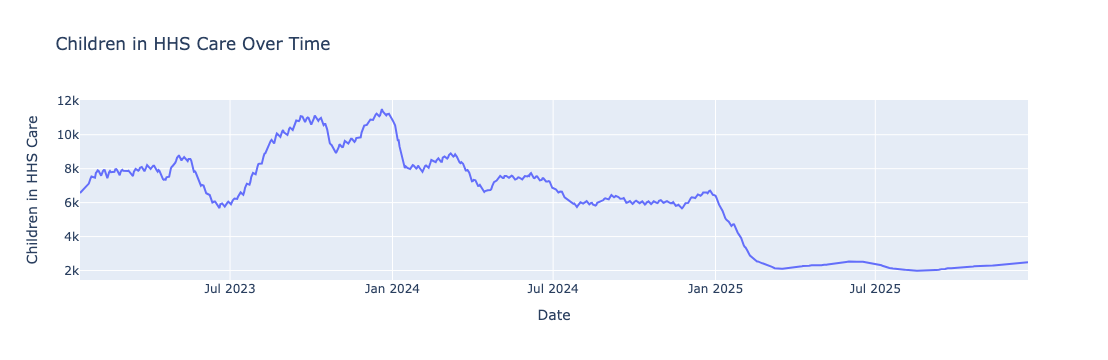

In [11]:
fig = px.line(
    df,
    x="Date",
    y="Children in HHS Care",
    title="Children in HHS Care Over Time"
)

fig.show()

## 📌 Observation

- The number of children in HHS Care shows noticeable changes over the observed period.
- There is a gradual decline in the later part of the dataset.
- A few periods exhibit sharper increases or decreases, indicating changing operational demand.

## 📊 Business Interpretation

- The HHS Care population is influenced by the balance between incoming transfers and outgoing discharges.
- The declining trend may indicate reduced admissions, increased discharges, or changes in policy and reporting practices.

## 💡 Key Insight

- This metric is the primary forecasting target and should be analyzed further for trend and seasonality before model development.

In [ ]:
columns = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

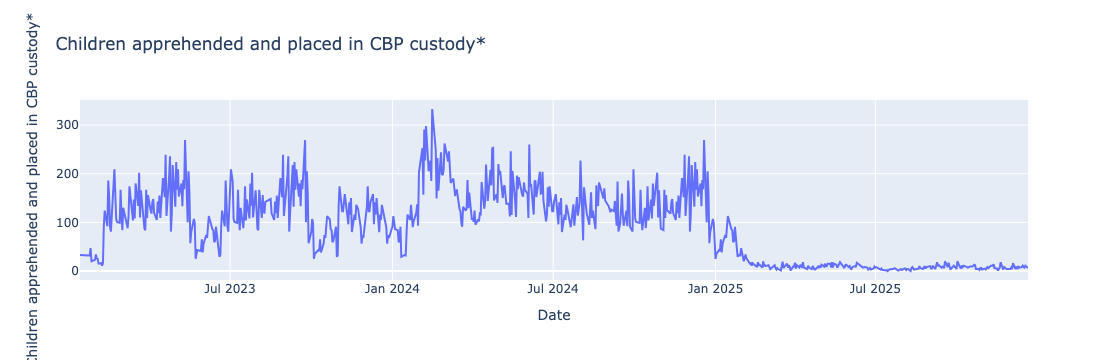

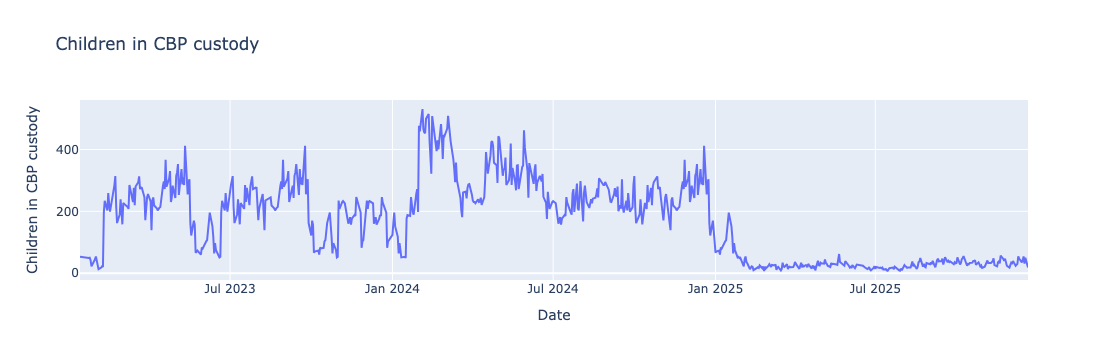

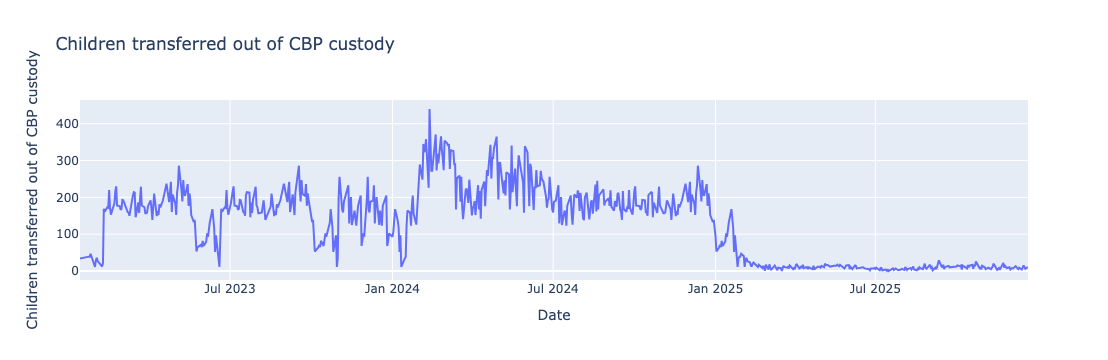

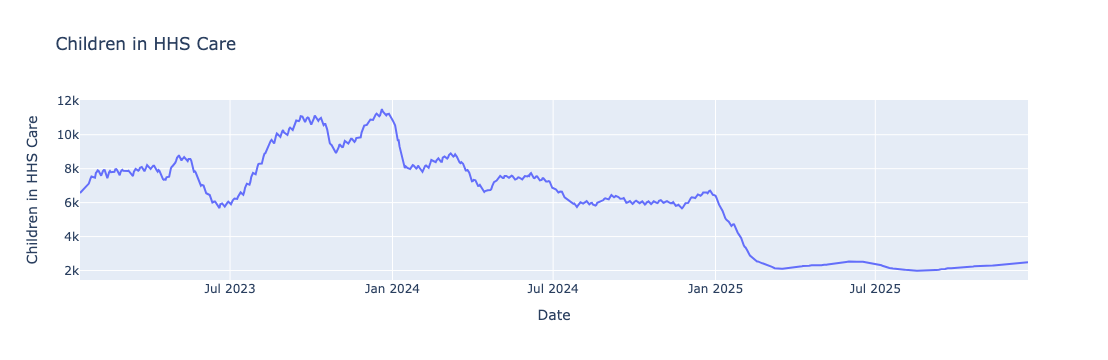

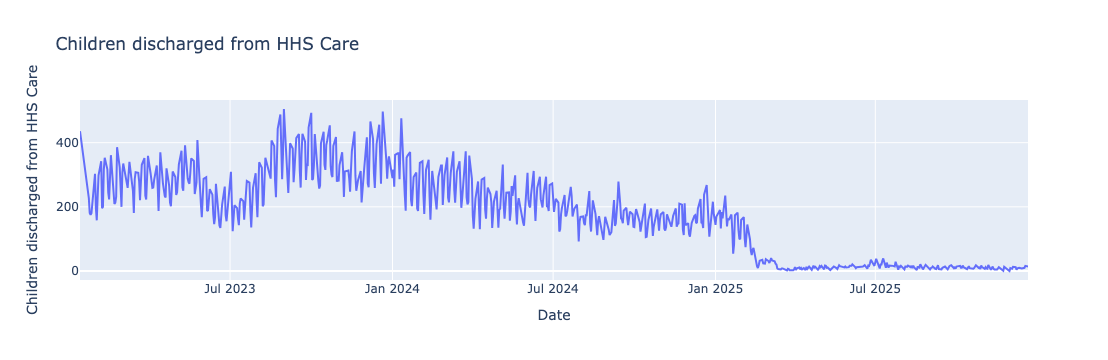

In [13]:
for column in columns:

    fig = px.line(
        df,
        x="Date",
        y=column,
        title=column
    )

    fig.show()

## 📌 Observation

- Daily discharge counts remain relatively stable with periodic fluctuations.
- No extreme spikes are observed.

## 📊 Business Interpretation

- Discharges represent the outflow from HHS care and directly influence occupancy levels.

## 💡 Key Insight

- Understanding discharge patterns is essential for predicting future HHS capacity requirements.

In [14]:
corr = df.drop(columns=["Date"]).corr()

corr

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Children apprehended and placed in CBP custody*,1.000000,0.950604,0.887896,0.691312,0.627755
Children in CBP custody,0.950604,1.000000,0.925039,0.663662,0.602144
Children transferred out of CBP custody,0.887896,0.925039,1.000000,0.713899,0.657322
Children in HHS Care,0.691312,0.663662,0.713899,1.000000,0.920881
Children discharged from HHS Care,0.627755,0.602144,0.657322,0.920881,1.000000


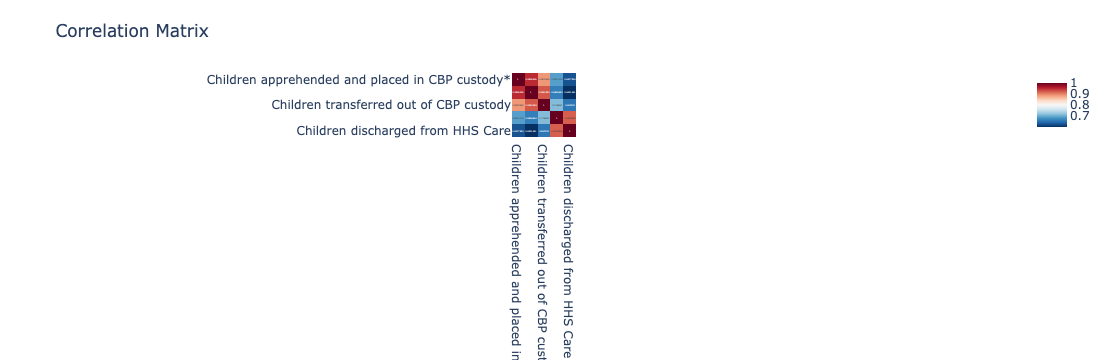

In [15]:
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Matrix"
)

fig.show()

## 📌 Observation

- Several variables exhibit strong positive correlations.
- Operational metrics generally move together rather than independently.

## 📊 Business Interpretation

- This indicates that different stages of the care pipeline are interconnected.

## 💡 Key Insight

- Strongly correlated variables can serve as valuable predictors in forecasting models.

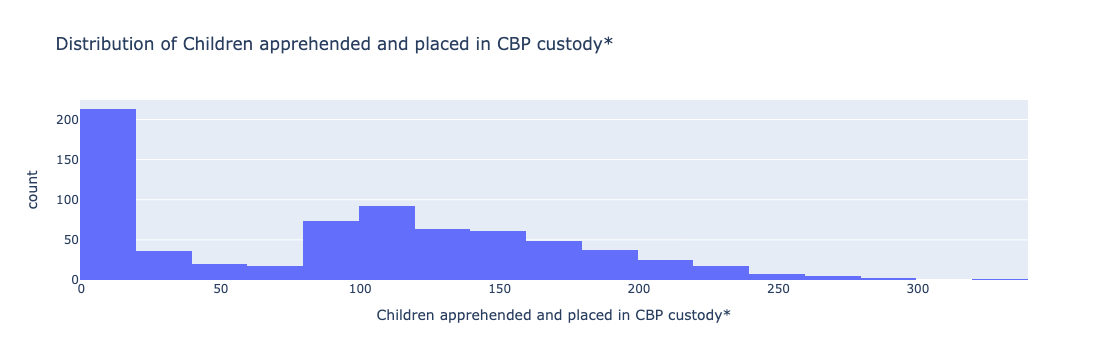

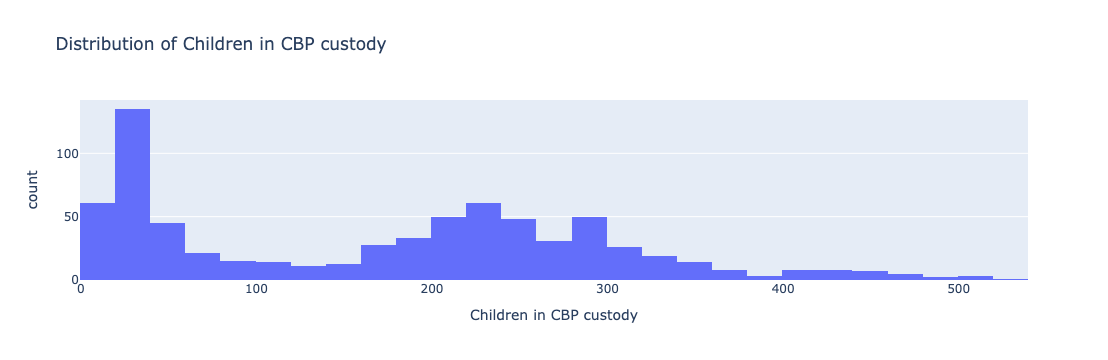

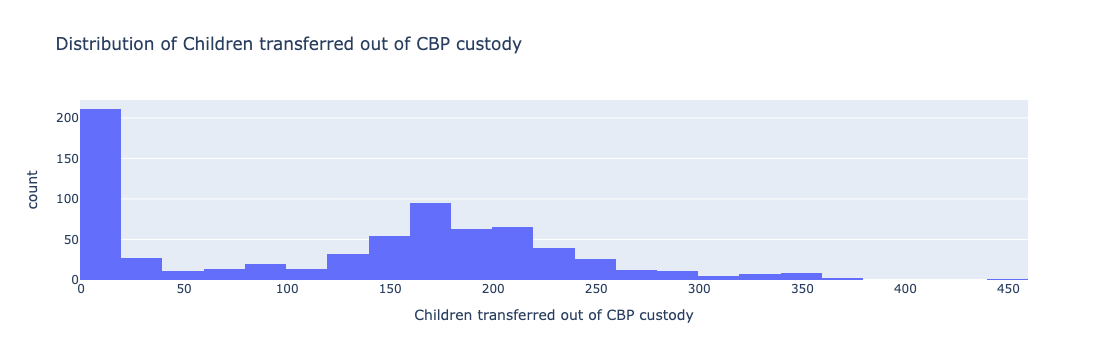

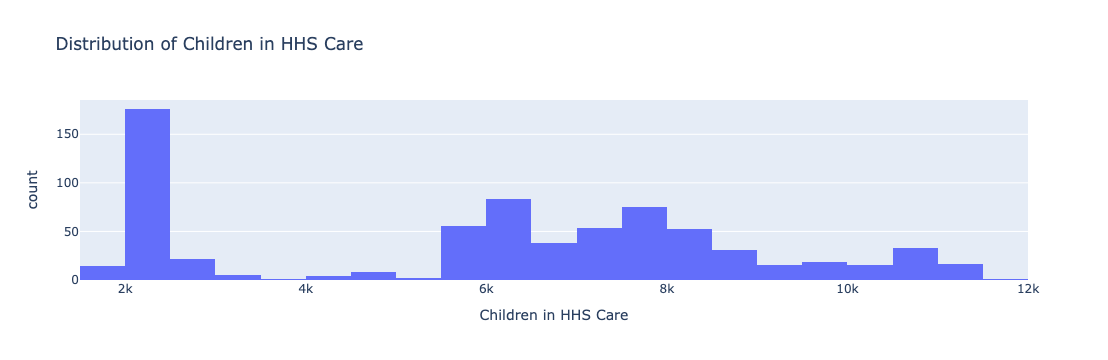

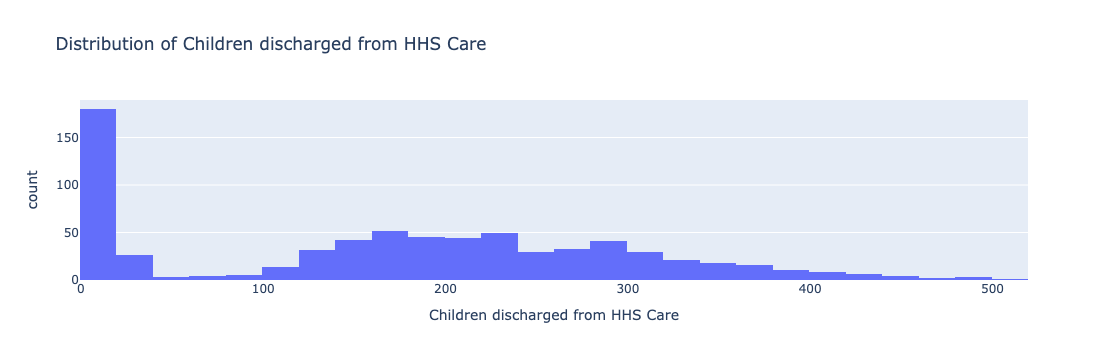

In [16]:
for column in columns:

    fig = px.histogram(
        df,
        x=column,
        nbins=30,
        title=f"Distribution of {column}"
    )

    fig.show()

## 📌 Observation

- Most variables are not normally distributed.
- Several metrics exhibit right-skewed distributions with higher frequencies at lower values.

## 📊 Business Interpretation

- The operational data reflects real-world variability rather than ideal statistical distributions.

## 💡 Key Insight

- Skewed distributions should be considered during feature engineering and model selection.

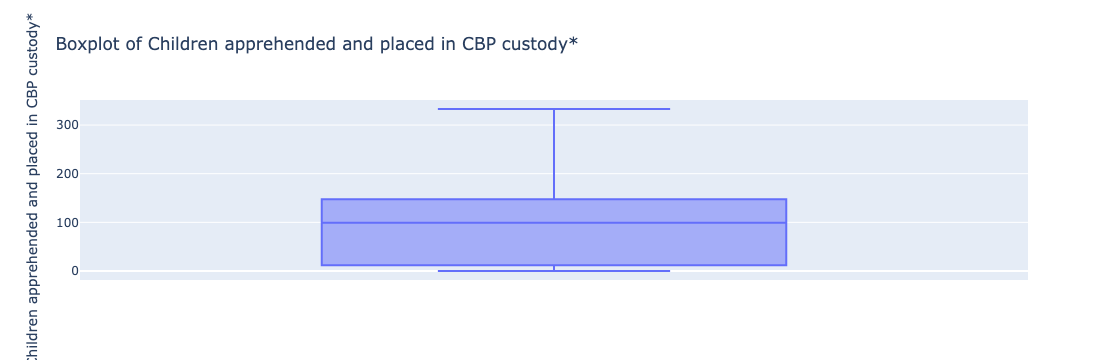

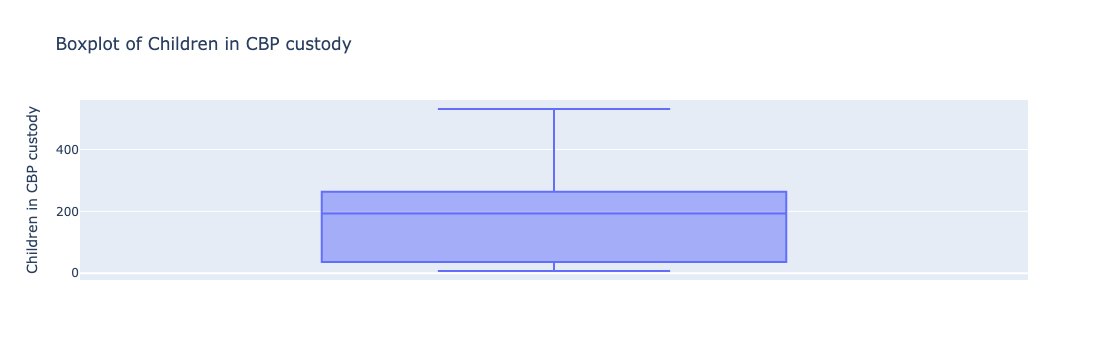

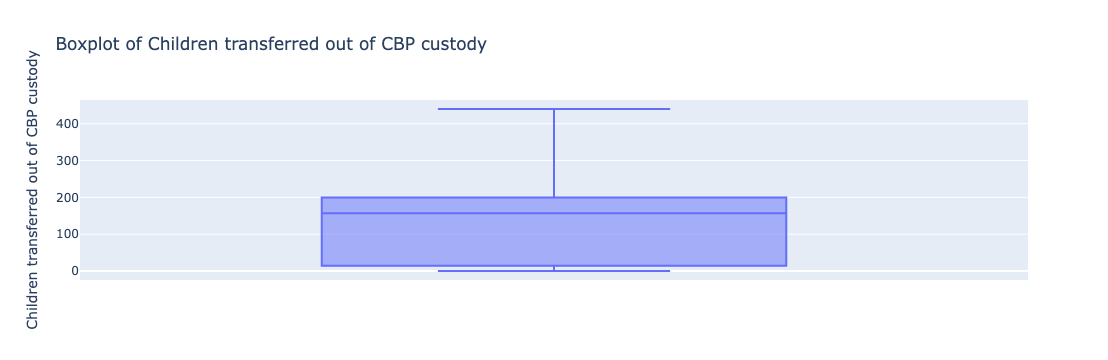

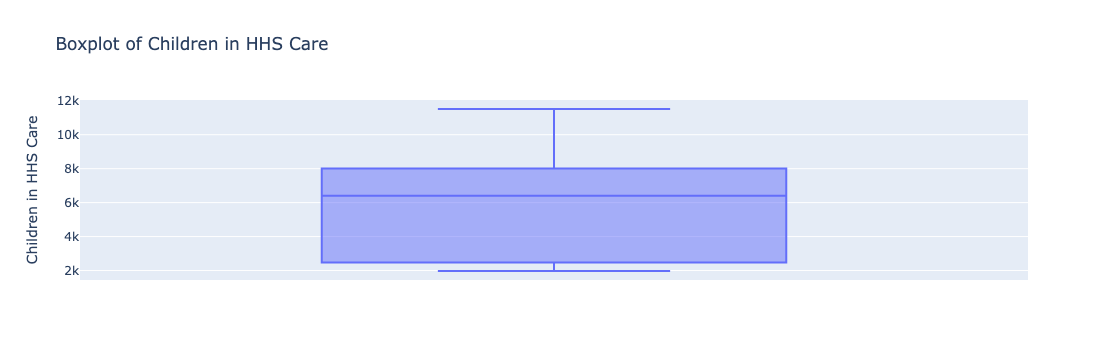

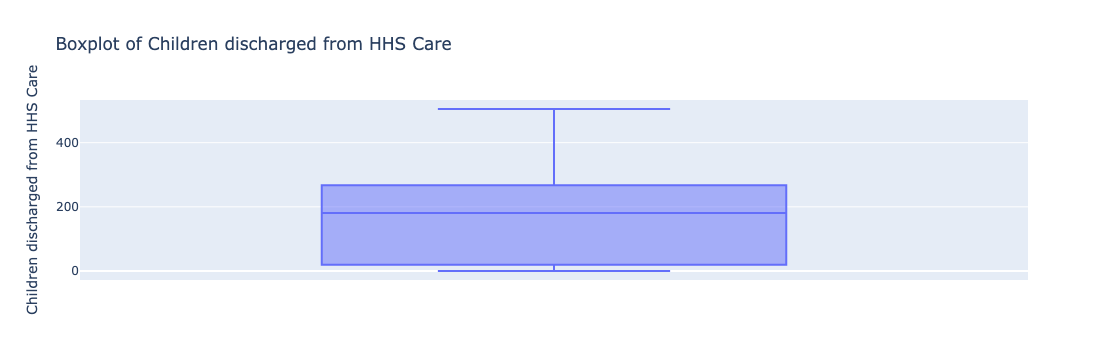

In [17]:
for column in columns:

    fig = px.box(
        df,
        y=column,
        title=f"Boxplot of {column}"
    )

    fig.show()

## 📌 Observation

- Most variables show moderate variability with a few observations extending toward higher values.
- No excessive number of extreme outliers is observed.

## 📊 Business Interpretation

- The dataset appears operationally stable while still capturing natural fluctuations.

## 💡 Key Insight

- Since extreme outliers are limited, minimal preprocessing is expected before modeling.

In [18]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

In [19]:
monthly = (
    df.groupby("Month")["Children in HHS Care"]
      .mean()
      .reset_index()
)

In [22]:
df.to_csv("../data/processed/clean_eda_data.csv", index=False)

# 📌 Overall EDA Summary

### Key Findings

- The dataset contains 720 valid daily observations after removing empty rows.
- The HHS Care population shows a long-term decline across the observation period.
- Operational metrics are positively correlated, indicating a connected care pipeline.
- Missing values were limited to completely empty rows and were safely removed.
- Most variables exhibit skewed distributions with moderate variability.
- The dataset is suitable for forecasting after feature engineering.

### Next Steps

- Perform feature engineering using lag features, rolling statistics, and calendar-based attributes.
- Develop forecasting models to predict future HHS Care capacity.
- Build an interactive Streamlit dashboard for operational monitoring and decision support.